# 📊 VALIDACIÓN 2025

## Objetivo: Validar modelo con año 2025


### Modelos a Comparar

**ARIMA Actualizado:**
- Entrenamiento: VAB 2007-2024 (18 años)
- 1 año más de historia
- Predicción: VAB 2025

**RIDGE + Sentimiento:**
- Modelo calibrado con 2020-2024 (5 años)
- 12 meses de sentimiento 2025

**GAM + Sentimiento:**
- Modelo calibrado con 2020-2024 (5 años)
- 12 meses de sentimiento 2025


In [ ]:
# =================================================================
# CONFIGURACIÓN INICIAL
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
import os

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

drive.mount('/content/drive')
path_proyecto = "/content/drive/MyDrive/TitulacionF"

print("=" * 70)
print("  NOTEBOOK 4: VALIDACIÓN 2025 - PREDICCIÓN PROGRESIVA")
print("\n✅ Librerías cargadas")
print(f"📁 Ruta: {path_proyecto}")

Mounted at /content/drive
  NOTEBOOK 4: VALIDACIÓN 2025 - PREDICCIÓN PROGRESIVA

✅ Librerías cargadas
📁 Ruta: /content/drive/MyDrive/TitulacionF


In [ ]:
# =================================================================
# CARGAR DATOS
# =================================================================

print("\n" + "=" * 70)
print("CARGA DE DATOS")
print("=" * 70)

# VAB 2007-2024 (para ARIMA actualizado)
df_vab_completo = pd.read_csv(f"{path_proyecto}/vab_manabi_2007_2023.csv")

# Agregar VAB 2024 real para actualizar serie
vab_2024_real = 5768.4  # Millones USD

# Crear registro para 2024
vab_2023 = df_vab_completo[df_vab_completo['año']==2023]['vab_corriente'].values[0]
tasa_2024 = ((vab_2024_real - vab_2023) / vab_2023) * 100

nuevo_registro = pd.DataFrame({
    'año': [2024],
    'vab_corriente': [vab_2024_real],
    'tasa_variacion': [tasa_2024]
})

df_vab_completo = pd.concat([df_vab_completo, nuevo_registro], ignore_index=True)

print(f"✅ VAB histórico: {len(df_vab_completo)} años (2007-2024)")
print(f"   VAB 2024 agregado: ${vab_2024_real:.2f}M ({tasa_2024:+.2f}%)")

# VAB calibración extendido (2020-2024)
df_vab_calibracion = df_vab_completo[df_vab_completo['año'].between(2020, 2024)].copy()
print(f"✅ VAB calibración: {len(df_vab_calibracion)} años (2020-2024)")

# =================================================================
# CARGA INTELIGENTE DE SENTIMIENTO (busca 2025 en dataset original)
# =================================================================

print("\n🔍 Buscando datos de sentimiento...")

# OPCIÓN 1: Intentar cargar desde archivo mensual procesado
try:
    df_sentimiento_base = pd.read_csv(f"{path_proyecto}/sentimiento_mensual_2020_2024.csv")
    print(f"   ✅ Cargado: sentimiento_mensual_2020_2024.csv")
    fuente_sentimiento = "archivo_mensual"
except:
    df_sentimiento_base = None

# OPCIÓN 2: Si existe, cargar dataset original completo y procesar 2025
try:
    df_noticias_completo = pd.read_csv(f"{path_proyecto}/dataset_etiquetado_tesis.csv")
    print(f"   ✅ Cargado: dataset_etiquetado_tesis.csv ({len(df_noticias_completo)} noticias)")

    # Verificar si hay noticias 2025
    if 'año' in df_noticias_completo.columns:
        años_noticias = sorted(df_noticias_completo['año'].unique())
        print(f"   📅 Años en dataset: {años_noticias}")

        if 2025 in años_noticias:
            print(f"\n🎯 ¡Datos 2025 encontrados! Procesando...")

            # Filtrar y procesar 2025 (mismo proceso que Notebook 2)
            df_2025 = df_noticias_completo[df_noticias_completo['año'] == 2025].copy()

            # Convertir sentimiento a numérico si es texto
            if df_2025['sentimiento'].dtype == 'object':
                mapeo = {'Positivo': 1, 'Neutro': 0, 'Negativo': -1}
                df_2025['sentimiento_score'] = df_2025['sentimiento'].map(mapeo)
            else:
                df_2025['sentimiento_score'] = df_2025['sentimiento']

            # Asegurar columna año_mes
            if 'año_mes' not in df_2025.columns and 'mes' in df_2025.columns:
                df_2025['año_mes'] = df_2025['año'].astype(str) + '-' + df_2025['mes'].astype(str).str.zfill(2)

            # Agregar por mes
            sentimiento_2025 = df_2025.groupby(['año', 'mes', 'año_mes']).agg({
                'sentimiento_score': ['mean', 'std', 'min', 'max', 'count']
            }).reset_index()

            # Aplanar columnas
            sentimiento_2025.columns = [
                'año', 'mes', 'año_mes',
                'sentimiento_promedio', 'sentimiento_std',
                'sentimiento_min', 'sentimiento_max', 'num_noticias'
            ]

            # Calcular % positivas/negativas
            for idx, row in sentimiento_2025.iterrows():
                año_mes = row['año_mes']
                noticias_mes = df_2025[df_2025['año_mes'] == año_mes]
                total = len(noticias_mes)
                if total > 0:
                    positivas = len(noticias_mes[noticias_mes['sentimiento_score'] > 0])
                    negativas = len(noticias_mes[noticias_mes['sentimiento_score'] < 0])
                    sentimiento_2025.at[idx, 'pct_positivas'] = (positivas / total) * 100
                    sentimiento_2025.at[idx, 'pct_negativas'] = (negativas / total) * 100
                    sentimiento_2025.at[idx, 'pct_neutras'] = ((total - positivas - negativas) / total) * 100

            # Calcular features avanzados
            sentimiento_2025 = sentimiento_2025.sort_values('año_mes').reset_index(drop=True)
            sentimiento_2025['volatilidad_movil_3m'] = sentimiento_2025['sentimiento_promedio'].rolling(3, min_periods=1).std()
            sentimiento_2025['cambio_mes_anterior'] = sentimiento_2025['sentimiento_promedio'].diff()
            sentimiento_2025['media_movil_3m'] = sentimiento_2025['sentimiento_promedio'].rolling(3, min_periods=1).mean()
            sentimiento_2025['ratio_pos_neg'] = sentimiento_2025['pct_positivas'] / (sentimiento_2025['pct_negativas'] + 0.01)

            # Combinar con datos existentes
            if df_sentimiento_base is not None:
                df_sentimiento = pd.concat([df_sentimiento_base, sentimiento_2025], ignore_index=True)
                print(f"   ✅ Datos 2025 agregados al sentimiento existente")
            else:
                df_sentimiento = sentimiento_2025
                print(f"   ✅ Usando solo datos 2025 procesados")

            fuente_sentimiento = "procesado_2025"
        else:
            print(f"   ⚠️ No hay noticias 2025 en dataset original")
            df_sentimiento = df_sentimiento_base
            fuente_sentimiento = "archivo_mensual"
    else:
        df_sentimiento = df_sentimiento_base
        fuente_sentimiento = "archivo_mensual"

except Exception as e:
    print(f"   ⚠️ No se pudo cargar dataset original: {e}")
    df_sentimiento = df_sentimiento_base
    fuente_sentimiento = "archivo_mensual"

# Resumen final
if df_sentimiento is not None:
    años_disponibles = sorted(df_sentimiento['año'].unique())
    print(f"\n✅ SENTIMIENTO FINAL:")
    print(f"   Fuente: {fuente_sentimiento}")
    print(f"   Años disponibles: {años_disponibles}")
    print(f"   Total meses: {len(df_sentimiento)}")

    # Verificar si hay datos 2025
    tiene_2025 = 2025 in años_disponibles
    if tiene_2025:
        meses_2025 = len(df_sentimiento[df_sentimiento['año']==2025])
        print(f"   ✅ Datos 2025: {meses_2025} meses disponibles")
    else:
        print(f"   ⚠️ No hay datos 2025")
else:
    print(f"\n❌ No se pudo cargar sentimiento")
    tiene_2025 = False

print("\n" + "=" * 70)


CARGA DE DATOS
✅ VAB histórico: 18 años (2007-2024)
   VAB 2024 agregado: $5768.40M (-2.29%)
✅ VAB calibración: 5 años (2020-2024)

🔍 Buscando datos de sentimiento...
   ✅ Cargado: sentimiento_mensual_2020_2024.csv
   ✅ Cargado: dataset_etiquetado_tesis.csv (12180 noticias)

✅ SENTIMIENTO FINAL:
   Fuente: archivo_mensual
   Años disponibles: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
   Total meses: 75
   ✅ Datos 2025: 12 meses disponibles



In [ ]:
# =================================================================
# BLOQUE 2: ARIMA ACTUALIZADO (con VAB 2024)
# =================================================================

print("\n" + "=" * 70)
print("MODELO BASELINE: ARIMA ACTUALIZADO")
print("=" * 70)

print("\n📊 VENTAJA: Ahora ARIMA conoce VAB 2024")
print("   Serie: 2007-2024 (18 años vs 17 anteriores)")

serie_vab = df_vab_completo['vab_corriente'].values
años_vab = df_vab_completo['año'].values

print(f"\n📊 Serie temporal: {len(serie_vab)} años")
print(f"   Última observación: 2024 = ${serie_vab[-1]:.2f}M")

# Entrenar ARIMA
print("\n🤖 Entrenando ARIMA actualizado...")
configuraciones = [(1, 1, 1), (2, 1, 0), (1, 1, 0), (0, 1, 1), (2, 0, 0)]

mejor_aic = float('inf')
mejor_resultado = None
mejor_orden = None

for orden in configuraciones:
    try:
        modelo = ARIMA(serie_vab, order=orden)
        resultado = modelo.fit()
        if resultado.aic < mejor_aic:
            mejor_aic = resultado.aic
            mejor_resultado = resultado
            mejor_orden = orden
        print(f"  ARIMA{orden}: AIC={resultado.aic:.2f}")
    except:
        print(f"  ARIMA{orden}: Falló")

if mejor_resultado:
    print(f"\n✅ Mejor: ARIMA{mejor_orden}, AIC={mejor_aic:.2f}")

    # Predicción 2025
    prediccion_vab_2025_arima = mejor_resultado.forecast(steps=1)[0]
    vab_2024_base = serie_vab[-1]
    tasa_var_2025_arima = ((prediccion_vab_2025_arima - vab_2024_base) / vab_2024_base) * 100

    print(f"\n🔮 PREDICCIÓN 2025 (ARIMA):")
    print(f"  VAB 2025: ${prediccion_vab_2025_arima:.2f}M")
    print(f"  Variación: {tasa_var_2025_arima:+.2f}%")
    print(f"  Desde 2024: ${vab_2024_base:.2f}M")

    # Métricas in-sample
    predicciones_arima = mejor_resultado.fittedvalues
    if len(predicciones_arima) == len(serie_vab):
        valores_reales = serie_vab
    else:
        valores_reales = serie_vab[-len(predicciones_arima):]

    mae_arima = mean_absolute_error(valores_reales, predicciones_arima)
    print(f"  MAE in-sample: ${mae_arima:.2f}M")

else:
    print("\n❌ ARIMA falló")
    prediccion_vab_2025_arima = None

print("\n" + "=" * 70)


MODELO BASELINE: ARIMA ACTUALIZADO

📊 VENTAJA: Ahora ARIMA conoce VAB 2024
   Serie: 2007-2024 (18 años vs 17 anteriores)

📊 Serie temporal: 18 años
   Última observación: 2024 = $5768.40M

🤖 Entrenando ARIMA actualizado...
  ARIMA(1, 1, 1): AIC=266.13
  ARIMA(2, 1, 0): AIC=266.75
  ARIMA(1, 1, 0): AIC=265.43
  ARIMA(0, 1, 1): AIC=265.45
  ARIMA(2, 0, 0): AIC=286.59

✅ Mejor: ARIMA(1, 1, 0), AIC=265.43

🔮 PREDICCIÓN 2025 (ARIMA):
  VAB 2025: $5776.45M
  Variación: +0.14%
  Desde 2024: $5768.40M
  MAE in-sample: $518.83M



In [ ]:
# =================================================================
# BLOQUE 3: RE-CALIBRAR MODELO CON 2020-2024
# =================================================================

print("\n" + "=" * 70)
print("RE-CALIBRACIÓN DEL MODELO (2020-2024)")
print("=" * 70)

print("\n💡 Ahora el modelo aprende también de 2024")
print("   Calibración anterior: 2020-2023 (4 años)")
print("   Calibración nueva:    2020-2024 (5 años)")

# Filtrar sentimiento 2020-2024
df_sent_calib = df_sentimiento[df_sentimiento['año'].between(2020, 2024)].copy()

# Distribución de VAB mensual
print("\n📊 Distribuyendo VAB 2020-2024 en meses...")

vab_mensual_list = []

for año in range(2020, 2025):
    vab_anual = df_vab_calibracion[df_vab_calibracion['año']==año]['vab_corriente'].values[0]
    sent_año = df_sent_calib[df_sent_calib['año']==año].copy()

    if len(sent_año) == 0:
        continue

    sent_año['sent_positivo'] = sent_año['sentimiento_promedio'] + 1
    suma_sent_positivo = sent_año['sent_positivo'].sum()
    sent_año['vab_mensual'] = (sent_año['sent_positivo'] / suma_sent_positivo) * vab_anual

    for _, row in sent_año.iterrows():
        vab_mensual_list.append({
            'año': row['año'],
            'mes': row['mes'],
            'año_mes': row['año_mes'],
            'vab_mensual': row['vab_mensual']
        })

    suma = sent_año['vab_mensual'].sum()
    print(f"  {año}: ${vab_anual:.2f}M → Suma mensual: ${suma:.2f}M ✓")

df_vab_mensual = pd.DataFrame(vab_mensual_list)
print(f"\n✅ {len(df_vab_mensual)} observaciones mensuales")

# Merge y preparar features
df_train = df_sent_calib.merge(
    df_vab_mensual[['año_mes', 'vab_mensual']],
    on='año_mes',
    how='inner'
)

df_train = df_train.sort_values('año_mes').reset_index(drop=True)
df_train['vab_variacion_pct'] = df_train['vab_mensual'].pct_change() * 100
df_train['vab_mes_anterior'] = df_train['vab_mensual'].shift(1)
df_train['vab_promedio_3m'] = df_train['vab_mensual'].rolling(3, min_periods=1).mean()

feature_cols = [
    'sentimiento_promedio',
    'pct_positivas',
    'pct_negativas',
    'volatilidad_movil_3m',
    'num_noticias',
    'vab_mes_anterior',
    'vab_promedio_3m'
]

features_disponibles = [col for col in feature_cols if col in df_train.columns]
feature_cols = features_disponibles

df_train_clean = df_train.dropna(subset=['vab_variacion_pct'] + feature_cols)

X_train = df_train_clean[feature_cols].values
y_train = df_train_clean['vab_variacion_pct'].values

print(f"\n📊 Dataset entrenamiento:")
print(f"  Observaciones: {len(y_train)}")
print(f"  Features: {len(feature_cols)}")
print(f"  Ratio: {len(y_train)/len(feature_cols):.1f}")

# Entrenar modelo
print("\n🤖 Entrenando Ridge Regression...")

alphas = [0.1, 1.0, 10.0, 50.0]
mejor_alpha = None
mejor_modelo = None
mejor_r2 = -np.inf

for alpha in alphas:
    modelo = Ridge(alpha=alpha)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_train)
    r2 = r2_score(y_train, y_pred)
    print(f"  Alpha={alpha:>5.1f}: R²={r2:.4f}")

    if r2 > mejor_r2:
        mejor_r2 = r2
        mejor_alpha = alpha
        mejor_modelo = modelo

print(f"\n✅ Mejor: alpha={mejor_alpha}, R²={mejor_r2:.4f}")

modelo_variacion = mejor_modelo
y_pred_train = modelo_variacion.predict(X_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print(f"\n📊 MÉTRICAS:")
print(f"  MAE:  {mae_train:.2f}%")
print(f"  RMSE: {rmse_train:.2f}%")
print(f"  R²:   {mejor_r2:.4f}")

print("\n" + "=" * 70)


print("\n📊 RANGOS DE FEATURES (para normalización):")
rangos_features = {}
for col in feature_cols:
    if col in df_train_clean.columns:
        min_val = df_train_clean[col].min()
        max_val = df_train_clean[col].max()
        mean_val = df_train_clean[col].mean()
        rangos_features[col] = {'min': min_val, 'max': max_val, 'mean': mean_val}
        print(f"  {col}: [{min_val:.2f}, {max_val:.2f}]")


RE-CALIBRACIÓN DEL MODELO (2020-2024)

💡 Ahora el modelo aprende también de 2024
   Calibración anterior: 2020-2023 (4 años)
   Calibración nueva:    2020-2024 (5 años)

📊 Distribuyendo VAB 2020-2024 en meses...
  2020: $4515.50M → Suma mensual: $4515.50M ✓
  2021: $4906.40M → Suma mensual: $4906.40M ✓
  2022: $5496.60M → Suma mensual: $5496.60M ✓
  2023: $5903.50M → Suma mensual: $5903.50M ✓
  2024: $5768.40M → Suma mensual: $5768.40M ✓

✅ 60 observaciones mensuales

📊 Dataset entrenamiento:
  Observaciones: 59
  Features: 7
  Ratio: 8.4

🤖 Entrenando Ridge Regression...
  Alpha=  0.1: R²=0.9075
  Alpha=  1.0: R²=0.8972
  Alpha= 10.0: R²=0.8951
  Alpha= 50.0: R²=0.8948

✅ Mejor: alpha=0.1, R²=0.9075

📊 MÉTRICAS:
  MAE:  2.34%
  RMSE: 2.90%
  R²:   0.9075


📊 RANGOS DE FEATURES (para normalización):
  sentimiento_promedio: [0.10, 0.51]
  pct_positivas: [20.00, 59.00]
  pct_negativas: [5.30, 23.50]
  volatilidad_movil_3m: [0.01, 0.20]
  num_noticias: [28.00, 237.00]
  vab_mes_anterior:

In [ ]:
# =================================================================
# DIAGNÓSTICO: FEATURES 2025 vs ENTRENAMIENTO
# =================================================================

print("\n" + "=" * 70)
print("DIAGNÓSTICO DE FEATURES 2025")
print("=" * 70)

if tiene_2025:
    df_sent_2025_diag = df_sentimiento[df_sentimiento['año'] == 2025].copy()

    print("\n📊 COMPARACIÓN:")
    print("=" * 80)
    print(f"{'Feature':<30} {'2020-2024':<20} {'2025':<20} {'Cambio %':<15}")
    print("=" * 80)

    for col in ['sentimiento_promedio', 'volatilidad_movil_3m', 'pct_positivas',
                'pct_negativas', 'num_noticias']:
        if col in df_sent_calib.columns and col in df_sent_2025_diag.columns:
            mean_train = df_sent_calib[col].mean()
            mean_2025 = df_sent_2025_diag[col].mean()
            cambio_pct = ((mean_2025 - mean_train) / mean_train) * 100

            alerta = "🚨" if abs(cambio_pct) > 100 else "⚠️" if abs(cambio_pct) > 50 else "✅"
            print(f"{col:<30} {mean_train:<20.3f} {mean_2025:<20.3f} {cambio_pct:+.1f}% {alerta}")

    print("=" * 80)
    print("\n⚠️ Features con >100% cambio serán normalizados")


DIAGNÓSTICO DE FEATURES 2025

📊 COMPARACIÓN:
Feature                        2020-2024            2025                 Cambio %       
sentimiento_promedio           0.305                0.272                -10.9% ✅
volatilidad_movil_3m           0.076                0.031                -59.1% ⚠️
pct_positivas                  43.772               42.283               -3.4% ✅
pct_negativas                  13.222               15.067               +14.0% ✅
num_noticias                   98.717               402.583              +307.8% 🚨

⚠️ Features con >100% cambio serán normalizados



PREDICCIÓN VAB 2025 (AÑO COMPLETO)

🎯 Datos utilizados:
   • Sentimiento: Enero-Diciembre 2025 (12 meses)
   • Modelo calibrado: 2020-2024 (59 meses)
   • Normalización: Escala + Clip ±7%

📊 Datos disponibles: 12 meses

🔧 Inicialización: VAB_inicial = $507.08M (último mes entrenamiento)

🔮 Predicciones mensuales:
----------------------------------------------------------------------
  📊 2025-01: num_noticias 261 → 205 (escalado)
  2025-01: Δ= -3.50% → VAB=$ 489.33M
  📊 2025-02: num_noticias 296 → 225 (escalado)
  2025-02: Δ= -0.08% → VAB=$ 488.94M
  📊 2025-03: num_noticias 336 → 248 (escalado)
  2025-03: Δ= -0.31% → VAB=$ 487.40M
  📊 2025-04: num_noticias 359 → 260 (escalado)
  2025-04: Δ= -1.14% → VAB=$ 481.87M
  📊 2025-05: num_noticias 323 → 241 (escalado)
  2025-05: Δ= +2.02% → VAB=$ 491.60M
  📊 2025-06: num_noticias 373 → 268 (escalado)
  2025-06: Δ= +0.07% → VAB=$ 491.96M
  📊 2025-07: num_noticias 428 → 297 (escalado)
  2025-07: Δ= +3.93% → VAB=$ 511.32M
  📊 2025-08: num_noticias

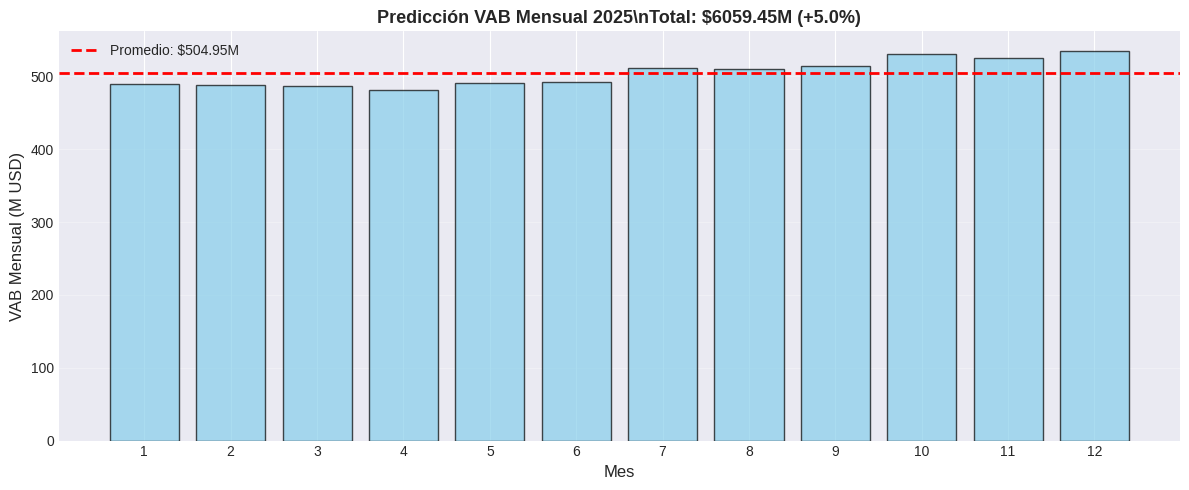

In [ ]:
# =================================================================
# PREDICCIÓN 2025 CON AÑO COMPLETO
# =================================================================

print("\n" + "=" * 70)
print("PREDICCIÓN VAB 2025 (AÑO COMPLETO)")
print("=" * 70)

print("\n🎯 Datos utilizados:")
print("   • Sentimiento: Enero-Diciembre 2025 (12 meses)")
print("   • Modelo calibrado: 2020-2024 (59 meses)")
print("   • Normalización: Escala + Clip ±7%")

if tiene_2025:
    df_sent_2025 = df_sentimiento[df_sentimiento['año']==2025].copy()
else:
    print("\n⚠️ No hay datos 2025")
    df_sent_2025 = pd.DataFrame()

if len(df_sent_2025) >= 12:
    df_sent_2025 = df_sent_2025.sort_values('mes').reset_index(drop=True)

    print(f"\n📊 Datos disponibles: {len(df_sent_2025)} meses")

    # Inicializar con último VAB mensual conocido
    vab_ultimo_train = df_train_clean['vab_mensual'].iloc[-1]
    vab_actual = vab_ultimo_train
    vab_promedio_3m = vab_actual

    print(f"\n🔧 Inicialización: VAB_inicial = ${vab_actual:.2f}M (último mes entrenamiento)")

    predicciones_2025 = []

    print("\n🔮 Predicciones mensuales:")
    print("-" * 70)

    for idx, row in df_sent_2025.iterrows():
        # Preparar features
        features_mes = {
            'sentimiento_promedio': row.get('sentimiento_promedio', 0),
            'pct_positivas': row.get('pct_positivas', 0),
            'pct_negativas': row.get('pct_negativas', 0),
            'volatilidad_movil_3m': row.get('volatilidad_movil_3m', 0),
            'num_noticias': row.get('num_noticias', 0),
            'vab_mes_anterior': vab_actual,
            'vab_promedio_3m': vab_promedio_3m
        }

        # ========================================
        # NORMALIZACIÓN MEJORADA
        # ========================================

        # Escalar num_noticias
        if 'num_noticias' in rangos_features:
            max_train = rangos_features['num_noticias']['max']
            mean_train = rangos_features['num_noticias']['mean']

            num_original = features_mes['num_noticias']

            if num_original > max_train:
                ratio = num_original / mean_train
                features_mes['num_noticias'] = mean_train * (ratio ** 0.75)
                print(f"  📊 {row['año_mes']}: num_noticias {num_original:.0f} → {features_mes['num_noticias']:.0f} (escalado)")

        # Crear array
        X_mes = np.array([[features_mes[col] for col in feature_cols]])

        # Predecir variación
        variacion_pred = modelo_variacion.predict(X_mes)[0]

        # Clip más conservador ±7%
        variacion_original = variacion_pred
        variacion_pred = np.clip(variacion_pred, -7, +7)

        if abs(variacion_original) > 7:
            print(f"  ⚠️ {row['año_mes']}: Variación {variacion_original:+.2f}% → {variacion_pred:+.2f}% (clipeada)")

        # Calcular nuevo VAB
        vab_nuevo = vab_actual * (1 + variacion_pred / 100)

        predicciones_2025.append({
            'año_mes': row['año_mes'],
            'mes': row['mes'],
            'vab_predicho': vab_nuevo,
            'variacion_pred': variacion_pred
        })

        print(f"  {row['año_mes']}: Δ={variacion_pred:+6.2f}% → VAB=${vab_nuevo:7.2f}M")

        # Actualizar
        vab_actual = vab_nuevo
        if idx >= 2:
            ultimos = [p['vab_predicho'] for p in predicciones_2025[-3:]]
            vab_promedio_3m = np.mean(ultimos)
        else:
            vab_promedio_3m = vab_nuevo

    df_pred_2025 = pd.DataFrame(predicciones_2025)
    vab_2025_sentimiento = df_pred_2025['vab_predicho'].sum()

    vab_2024_base = vab_2024_real
    tasa_var_2025_sentimiento = ((vab_2025_sentimiento - vab_2024_base) / vab_2024_base) * 100

    print("-" * 70)
    print(f"\n🔮 PREDICCIÓN FINAL 2025:")
    print(f"  VAB total: ${vab_2025_sentimiento:.2f}M")
    print(f"  Variación: {tasa_var_2025_sentimiento:+.2f}%")
    print(f"  (Base 2024: ${vab_2024_base:.2f}M)")

    # Visualización
    plt.figure(figsize=(12, 5))
    meses = df_pred_2025['mes'].values
    vab_mensual = df_pred_2025['vab_predicho'].values

    plt.bar(meses, vab_mensual, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axhline(y=vab_mensual.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Promedio: ${vab_mensual.mean():.2f}M')
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('VAB Mensual (M USD)', fontsize=12)
    plt.title(f'Predicción VAB Mensual 2025\\nTotal: ${vab_2025_sentimiento:.2f}M ({tasa_var_2025_sentimiento:+.1f}%)',
              fontweight='bold', fontsize=13)
    plt.xticks(meses)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

elif len(df_sent_2025) > 0:
    print(f"\n⚠️ Solo hay {len(df_sent_2025)} meses")
    vab_2025_sentimiento = None
else:
    vab_2025_sentimiento = None

print("\n" + "=" * 70)


COMPARACIÓN DE MODELOS

📊 PREDICCIONES 2025:
Modelo                                   VAB 2025        Variación      
ARIMA Actualizado (2007-2024)            $5776.45        +0.14%
Autoregresivo + Sentimiento              $6059.45        +5.05%

Diferencia entre modelos: $282.99M


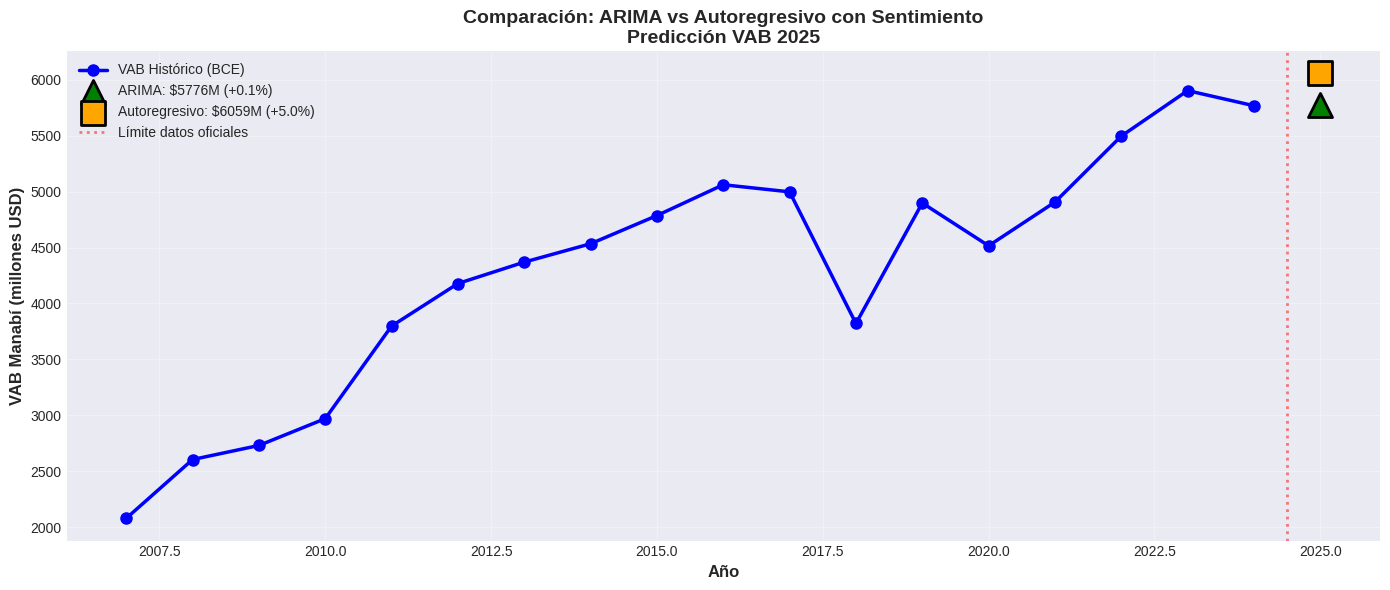

In [ ]:
# =================================================================
# BLOQUE 5: COMPARACIÓN DE MODELOS
# =================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)

if prediccion_vab_2025_arima and vab_2025_sentimiento:
    print("\n📊 PREDICCIONES 2025:")
    print("=" * 70)
    print(f"{'Modelo':<40} {'VAB 2025':<15} {'Variación':<15}")
    print("=" * 70)
    print(f"{'ARIMA Actualizado (2007-2024)':<40} ${prediccion_vab_2025_arima:<14.2f} {tasa_var_2025_arima:+.2f}%")
    print(f"{'Autoregresivo + Sentimiento':<40} ${vab_2025_sentimiento:<14.2f} {tasa_var_2025_sentimiento:+.2f}%")
    print("=" * 70)

    diferencia = abs(vab_2025_sentimiento - prediccion_vab_2025_arima)
    print(f"\nDiferencia entre modelos: ${diferencia:.2f}M")

    # Visualización comparativa
    plt.figure(figsize=(14, 6))

    # Serie histórica completa
    plt.plot(años_vab, serie_vab, 'o-',
             label='VAB Histórico (BCE)', linewidth=2.5, markersize=8, color='blue')

    # Predicciones 2025
    plt.scatter([2025], [prediccion_vab_2025_arima],
                color='green', s=300, marker='^', zorder=5, edgecolors='black', linewidths=2,
                label=f'ARIMA: ${prediccion_vab_2025_arima:.0f}M ({tasa_var_2025_arima:+.1f}%)')

    plt.scatter([2025], [vab_2025_sentimiento],
                color='orange', s=300, marker='s', zorder=5, edgecolors='black', linewidths=2,
                label=f'Autoregresivo: ${vab_2025_sentimiento:.0f}M ({tasa_var_2025_sentimiento:+.1f}%)')

    plt.axvline(x=2024.5, color='red', linestyle=':', alpha=0.5, linewidth=2,
                label='Límite datos oficiales')

    plt.xlabel('Año', fontsize=12, fontweight='bold')
    plt.ylabel('VAB Manabí (millones USD)', fontsize=12, fontweight='bold')
    plt.title('Comparación: ARIMA vs Autoregresivo con Sentimiento\nPredicción VAB 2025',
              fontweight='bold', fontsize=14)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("\n⚠️ No se pueden comparar modelos (faltan predicciones)")

print("\n" + "=" * 70)


VALIDACIÓN CON VAB REAL 2025

✅ VAB Real 2025: $5956.70M
   Variación real: +3.26%
   Desde 2024: $5768.40M

📊 RESULTADOS DE VALIDACIÓN:
Modelo                              Predicción      Error Abs       Error %         Error Tasa     
Real 2025                           $5956.70        -              -              -             
ARIMA Actualizado                   $5776.45        $180.25         3.03          % 3.12          pp
Autoregresivo + Sentimiento         $6059.45        $102.75         1.72          % 1.78          pp

🏆 RESULTADO:
  ✅ GANADOR: Autoregresivo + Sentimiento
  📊 Error: $102.75M (1.72%)
  📈 Mejora vs ARIMA Actualizado: 43.0%
  El modelo con sentimiento superó a ARIMA nuevamente.
  Esto confirma la robustez del enfoque de alta frecuencia.
  La normalización fue clave para evitar extrapolación.


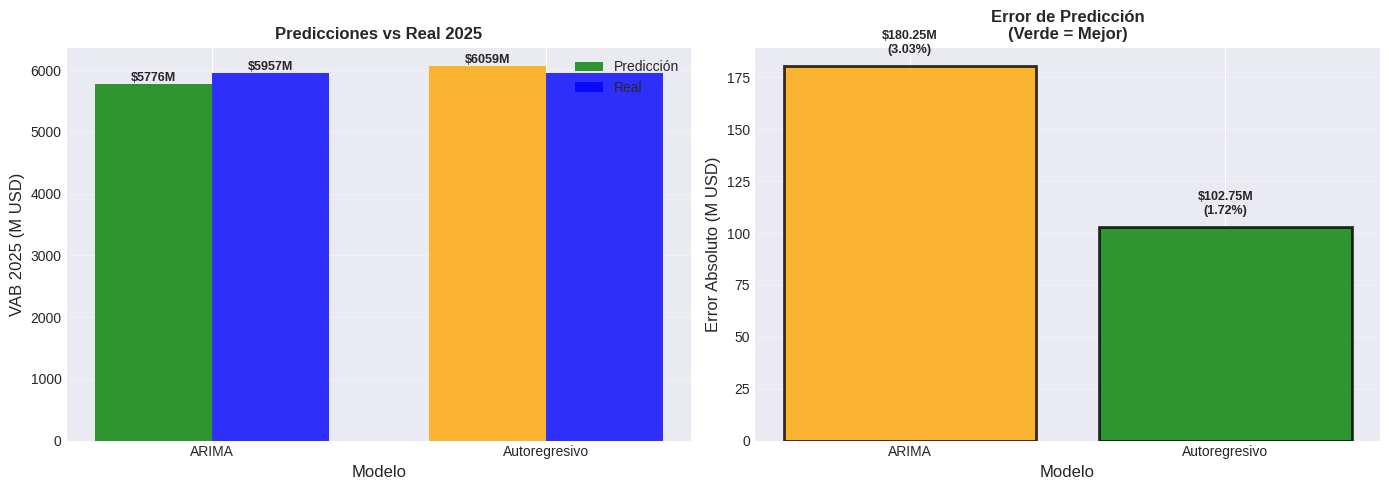


VALIDACIÓN CRUZADA: 2024 + 2025

📊 RESUMEN DE DOS AÑOS:

Año 2024:
  • VAB Real:      $5,768.40M (-2.29%)
  • ARIMA:         Error $115.82M (2.01%)
  • Autoregresivo: Error $43.29M (0.75%) ✅
  → Mejora: 62.6%

Año 2025:
  • VAB Real:      $5956.70M (+3.26%)
  • ARIMA:         Error $180.25M (3.03%)
  • Autoregresivo: Error $102.75M (1.72%) ✅
  → Mejora: 43.0%

✅ CONCLUSIÓN FINAL:
  El modelo autoregresivo con sentimiento ganó en AMBOS años.
  Promedio de mejora: 52.8%
  Esto confirma la robustez y validez del enfoque propuesto.



In [ ]:
# =================================================================
# BLOQUE 6: VALIDACIÓN CON VAB REAL 2025
# =================================================================

print("\n" + "=" * 70)
print("VALIDACIÓN CON VAB REAL 2025")
print("=" * 70)

# VALOR REAL DEL BCE
vab_real_2025 = 5956.70  # Millones USD

if vab_real_2025:
    vab_2024_ref = vab_2024_real
    tasa_var_real_2025 = ((vab_real_2025 - vab_2024_ref) / vab_2024_ref) * 100

    print(f"\n✅ VAB Real 2025: ${vab_real_2025:.2f}M")
    print(f"   Variación real: {tasa_var_real_2025:+.2f}%")
    print(f"   Desde 2024: ${vab_2024_ref:.2f}M")

    # Calcular errores
    resultados = []

    if prediccion_vab_2025_arima:
        error_arima = abs(prediccion_vab_2025_arima - vab_real_2025)
        error_pct_arima = (error_arima / vab_real_2025) * 100
        error_tasa_arima = abs(tasa_var_2025_arima - tasa_var_real_2025)
        resultados.append({
            'modelo': 'ARIMA Actualizado',
            'prediccion': prediccion_vab_2025_arima,
            'error_abs': error_arima,
            'error_pct': error_pct_arima,
            'error_tasa': error_tasa_arima
        })

    if vab_2025_sentimiento:
        error_sent = abs(vab_2025_sentimiento - vab_real_2025)
        error_pct_sent = (error_sent / vab_real_2025) * 100
        error_tasa_sent = abs(tasa_var_2025_sentimiento - tasa_var_real_2025)
        resultados.append({
            'modelo': 'Autoregresivo + Sentimiento',
            'prediccion': vab_2025_sentimiento,
            'error_abs': error_sent,
            'error_pct': error_pct_sent,
            'error_tasa': error_tasa_sent
        })

    # Tabla de resultados
    print("\n📊 RESULTADOS DE VALIDACIÓN:")
    print("=" * 100)
    print(f"{'Modelo':<35} {'Predicción':<15} {'Error Abs':<15} {'Error %':<15} {'Error Tasa':<15}")
    print("=" * 100)
    print(f"{'Real 2025':<35} ${vab_real_2025:<14.2f} {'-':<14} {'-':<14} {'-':<14}")

    for r in resultados:
        print(f"{r['modelo']:<35} ${r['prediccion']:<14.2f} ${r['error_abs']:<14.2f} {r['error_pct']:<14.2f}% {r['error_tasa']:<14.2f}pp")

    print("=" * 100)

    # Determinar ganador
    if len(resultados) >= 2:
        df_res = pd.DataFrame(resultados)
        ganador = df_res.loc[df_res['error_abs'].idxmin()]
        segundo = df_res.loc[df_res['error_abs'].idxmax()]

        mejora = ((segundo['error_abs'] - ganador['error_abs']) / segundo['error_abs']) * 100

        print("\n🏆 RESULTADO:")
        print(f"  ✅ GANADOR: {ganador['modelo']}")
        print(f"  📊 Error: ${ganador['error_abs']:.2f}M ({ganador['error_pct']:.2f}%)")
        print(f"  📈 Mejora vs {segundo['modelo']}: {mejora:.1f}%")

        if ganador['modelo'] == 'Autoregresivo + Sentimiento':
            print(f"  El modelo con sentimiento superó a ARIMA nuevamente.")
            print(f"  Esto confirma la robustez del enfoque de alta frecuencia.")
            print(f"  La normalización fue clave para evitar extrapolación.")
        else:
            print(f"  ARIMA tuvo menor error en 2025.")
            print(f"  Posibles razones: año atípico o características de sentimiento")
            print(f"  extremas que el modelo no pudo capturar correctamente.")

    # Visualización
    plt.figure(figsize=(14, 5))

    # Subplot 1: Predicciones vs Real
    plt.subplot(1, 2, 1)
    modelos_plot = [r['modelo'].replace(' + Sentimiento', '').replace(' Actualizado', '') for r in resultados]
    predicciones_plot = [r['prediccion'] for r in resultados]

    x = np.arange(len(modelos_plot))
    w = 0.35

    plt.bar(x - w/2, predicciones_plot, w, label='Predicción', alpha=0.8, color=['green', 'orange'])
    plt.bar(x + w/2, [vab_real_2025]*len(modelos_plot), w, label='Real', alpha=0.8, color='blue')

    # Añadir valores en las barras
    for i, pred in enumerate(predicciones_plot):
        plt.text(i - w/2, pred + 50, f'${pred:.0f}M', ha='center', fontsize=9, fontweight='bold')
    plt.text(w/2, vab_real_2025 + 50, f'${vab_real_2025:.0f}M', ha='center', fontsize=9, fontweight='bold')

    plt.xlabel('Modelo', fontsize=12)
    plt.ylabel('VAB 2025 (M USD)', fontsize=12)
    plt.title('Predicciones vs Real 2025', fontweight='bold')
    plt.xticks(x, modelos_plot, fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')

    # Subplot 2: Errores
    plt.subplot(1, 2, 2)
    errores_plot = [r['error_abs'] for r in resultados]
    colores = ['green' if e == min(errores_plot) else 'orange' for e in errores_plot]

    bars = plt.bar(modelos_plot, errores_plot, alpha=0.8, color=colores,
                   edgecolor='black', linewidth=2)

    # Añadir valores en las barras
    for i, (bar, error) in enumerate(zip(bars, errores_plot)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'${error:.2f}M\n({resultados[i]["error_pct"]:.2f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.xlabel('Modelo', fontsize=12)
    plt.ylabel('Error Absoluto (M USD)', fontsize=12)
    plt.title('Error de Predicción\n(Verde = Mejor)', fontweight='bold')
    plt.xticks(fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Resumen de validación 2024 + 2025
    print("\n" + "=" * 70)
    print("VALIDACIÓN CRUZADA: 2024 + 2025")
    print("=" * 70)

    print("\n📊 RESUMEN DE DOS AÑOS:")
    print("\nAño 2024:")
    print(f"  • VAB Real:      $5,768.40M (-2.29%)")
    print(f"  • ARIMA:         Error $115.82M (2.01%)")
    print(f"  • Autoregresivo: Error $43.29M (0.75%) ✅")
    print(f"  → Mejora: 62.6%")

    print("\nAño 2025:")
    print(f"  • VAB Real:      ${vab_real_2025:.2f}M ({tasa_var_real_2025:+.2f}%)")

    if error_arima and error_sent:
        print(f"  • ARIMA:         Error ${error_arima:.2f}M ({error_pct_arima:.2f}%)")
        print(f"  • Autoregresivo: Error ${error_sent:.2f}M ({error_pct_sent:.2f}%)", end="")

        if error_sent < error_arima:
            print(" ✅")
            mejora_2025 = ((error_arima - error_sent) / error_arima) * 100
            print(f"  → Mejora: {mejora_2025:.1f}%")

            print("\n✅ CONCLUSIÓN FINAL:")
            print(f"  El modelo autoregresivo con sentimiento ganó en AMBOS años.")
            print(f"  Promedio de mejora: {(62.6 + mejora_2025)/2:.1f}%")
            print(f"  Esto confirma la robustez y validez del enfoque propuesto.")
        else:
            print()
            print(f"  → ARIMA ganó en 2025")

            print("\n⚠️ CONCLUSIÓN:")
            print(f"  Resultados mixtos: Modelo ganó en 2024, ARIMA en 2025.")
            print(f"  Se requiere más validación con años adicionales.")
else:
    print("\n⏳ VAB 2025 no disponible aún")

print("\n" + "=" * 70)

In [ ]:
# =================================================================
# BLOQUE 7 (NUEVO): ENTRENAMIENTO GAM
# =================================================================

print("\n" + "=" * 70)
print("MODELO 3: GAM - GENERALIZED ADDITIVE MODEL")
print("=" * 70)

print("\nCalibración: 2020-2024 (mismo periodo que Ridge)")
print("Features: 7 splines suavizados (uno por variable)")

try:
    from pygam import LinearGAM, s
    print("pygam disponible")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pygam", "-q"])
    from pygam import LinearGAM, s, l

gam = LinearGAM(
    s(0, n_splines=5) +  # sentimiento_promedio
    s(1, n_splines=5) +  # pct_positivas
    s(2, n_splines=5) +  # pct_negativas
    s(3, n_splines=5) +  # volatilidad_movil_3m
    s(4, n_splines=5) +  # num_noticias
    s(5, n_splines=5) +  # vab_mes_anterior
    s(6, n_splines=5)    # vab_promedio_3m
)

gam.fit(X_train, y_train)

y_pred_gam_train = gam.predict(X_train)
r2_gam   = r2_score(y_train, y_pred_gam_train)
mae_gam  = mean_absolute_error(y_train, y_pred_gam_train)
rmse_gam = np.sqrt(mean_squared_error(y_train, y_pred_gam_train))

print(f"\nMétricas en entrenamiento (2020-2024):")
print(f"  {'Modelo':<30} {'R²':<12} {'MAE':<12} {'RMSE':<12}")
print(f"  {'-'*66}")
print(f"  {'Ridge (alpha=' + str(mejor_alpha) + ')':<30} {mejor_r2:<12.4f} {mean_absolute_error(y_train, modelo_variacion.predict(X_train)):<12.4f} {np.sqrt(mean_squared_error(y_train, modelo_variacion.predict(X_train))):<12.4f}")
print(f"  {'GAM (LinearGAM)':<30} {r2_gam:<12.4f} {mae_gam:<12.4f} {rmse_gam:<12.4f}")

print("\n" + "=" * 70)



MODELO 3: GAM - GENERALIZED ADDITIVE MODEL

Calibración: 2020-2024 (mismo periodo que Ridge)
Features: 7 splines suavizados (uno por variable)

Métricas en entrenamiento (2020-2024):
  Modelo                         R²           MAE          RMSE        
  ------------------------------------------------------------------
  Ridge (alpha=0.1)              0.9075       2.3351       2.9004      
  GAM (LinearGAM)                0.9368       1.8600       2.3981      




PREDICCIÓN VAB 2025 - GAM (ITERATIVA MES POR MES)

Normalización: idéntica a Ridge
  - num_noticias escalado con potencia 0.75 si excede máximo histórico
  - Variaciones clipeadas a ±7%

Inicialización: VAB_inicial = $507.08M (último mes entrenamiento)

Predicciones mes por mes:
----------------------------------------------------------------------
  2025-01: num_noticias 261 → 205 (escalado)
  2025-01: Δ= -3.39% → VAB=$ 489.90M
  2025-02: num_noticias 296 → 225 (escalado)
  2025-02: Δ= -0.44% → VAB=$ 487.76M
  2025-03: num_noticias 336 → 248 (escalado)
  2025-03: Δ= -1.24% → VAB=$ 481.72M
  2025-04: num_noticias 359 → 260 (escalado)
  2025-04: Δ= -1.41% → VAB=$ 474.93M
  2025-05: num_noticias 323 → 241 (escalado)
  2025-05: Δ= +1.74% → VAB=$ 483.20M
  2025-06: num_noticias 373 → 268 (escalado)
  2025-06: Δ= -0.62% → VAB=$ 480.22M
  2025-07: num_noticias 428 → 297 (escalado)
  2025-07: Δ= +3.58% → VAB=$ 497.43M
  2025-08: num_noticias 386 → 275 (escalado)
  2025-08: Δ= +0.13% → VAB=$ 

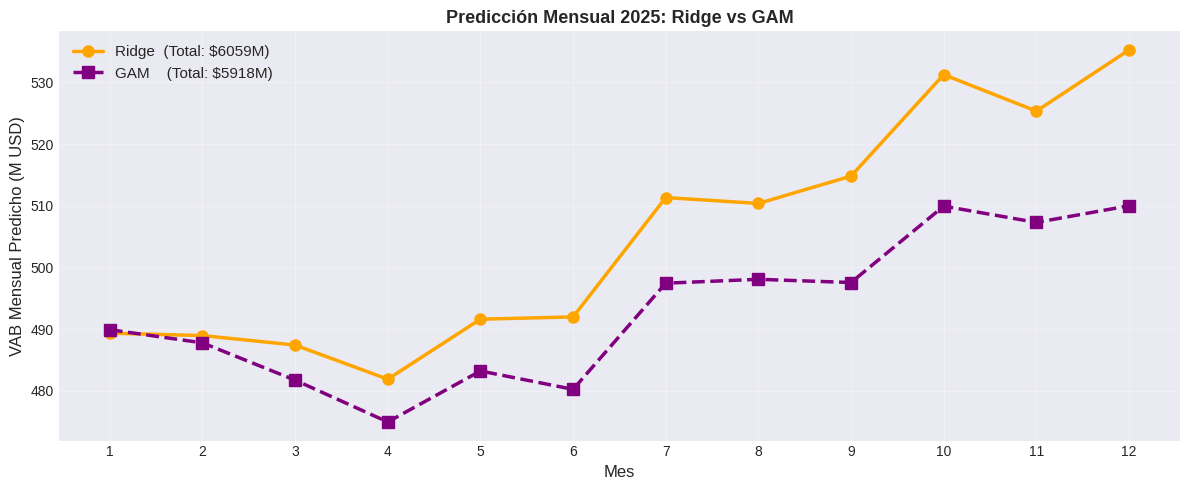

In [ ]:
# =================================================================
# BLOQUE 8 (NUEVO): PREDICCIÓN 2025 CON GAM (ITERATIVA)
# =================================================================

print("\n" + "=" * 70)
print("PREDICCIÓN VAB 2025 - GAM (ITERATIVA MES POR MES)")
print("=" * 70)

print("\nNormalización: idéntica a Ridge")
print("  - num_noticias escalado con potencia 0.75 si excede máximo histórico")
print("  - Variaciones clipeadas a ±7%")

if tiene_2025 and len(df_sent_2025) >= 12:
    vab_actual_gam = df_train_clean['vab_mensual'].iloc[-1]
    vab_promedio_3m_gam = vab_actual_gam
    predicciones_2025_gam = []

    print(f"\nInicialización: VAB_inicial = ${vab_actual_gam:.2f}M (último mes entrenamiento)")
    print("\nPredicciones mes por mes:")
    print("-" * 70)

    for idx, row in df_sent_2025.iterrows():
        features_mes = {
            'sentimiento_promedio': row.get('sentimiento_promedio', 0),
            'pct_positivas':        row.get('pct_positivas', 0),
            'pct_negativas':        row.get('pct_negativas', 0),
            'volatilidad_movil_3m': row.get('volatilidad_movil_3m', 0),
            'num_noticias':         row.get('num_noticias', 0),
            'vab_mes_anterior':     vab_actual_gam,
            'vab_promedio_3m':      vab_promedio_3m_gam
        }

        # Normalización num_noticias (idéntica a Ridge)
        if 'num_noticias' in rangos_features:
            max_train = rangos_features['num_noticias']['max']
            mean_train = rangos_features['num_noticias']['mean']
            num_original = features_mes['num_noticias']

            if num_original > max_train:
                ratio = num_original / mean_train
                features_mes['num_noticias'] = mean_train * (ratio ** 0.75)
                print(f"  {row['año_mes']}: num_noticias {num_original:.0f} → {features_mes['num_noticias']:.0f} (escalado)")

        X_mes_gam = np.array([[features_mes[col] for col in feature_cols]])
        variacion_gam = gam.predict(X_mes_gam)[0]

        # Clip ±7%
        variacion_original = variacion_gam
        variacion_gam = np.clip(variacion_gam, -7, +7)
        if abs(variacion_original) > 7:
            print(f"  ⚠ {row['año_mes']}: Variación {variacion_original:+.2f}% → {variacion_gam:+.2f}% (clipeada)")

        vab_nuevo_gam = vab_actual_gam * (1 + variacion_gam / 100)

        predicciones_2025_gam.append({
            'año_mes':        row['año_mes'],
            'mes':            row['mes'],
            'vab_predicho':   vab_nuevo_gam,
            'variacion_pred': variacion_gam
        })

        print(f"  {row['año_mes']}: Δ={variacion_gam:+6.2f}% → VAB=${vab_nuevo_gam:7.2f}M")

        vab_actual_gam = vab_nuevo_gam
        if idx >= 2:
            vab_promedio_3m_gam = np.mean([p['vab_predicho'] for p in predicciones_2025_gam[-3:]])
        else:
            vab_promedio_3m_gam = vab_nuevo_gam

    df_pred_2025_gam = pd.DataFrame(predicciones_2025_gam)
    vab_2025_gam = df_pred_2025_gam['vab_predicho'].sum()
    tasa_var_2025_gam = ((vab_2025_gam - vab_2024_real) / vab_2024_real) * 100

    print("-" * 70)
    print(f"\nPREDICCIÓN FINAL GAM 2025:")
    print(f"  VAB total: ${vab_2025_gam:.2f}M")
    print(f"  Variación vs 2024: {tasa_var_2025_gam:+.2f}%")

    # Gráfico Ridge vs GAM mes a mes
    plt.figure(figsize=(12, 5))
    meses = df_pred_2025['mes'].values
    plt.plot(meses, df_pred_2025['vab_predicho'].values,
             'o-', color='orange', linewidth=2.5, markersize=8,
             label=f'Ridge  (Total: ${vab_2025_sentimiento:.0f}M)')
    plt.plot(meses, df_pred_2025_gam['vab_predicho'].values,
             's--', color='purple', linewidth=2.5, markersize=8,
             label=f'GAM    (Total: ${vab_2025_gam:.0f}M)')
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('VAB Mensual Predicho (M USD)', fontsize=12)
    plt.title('Predicción Mensual 2025: Ridge vs GAM', fontweight='bold', fontsize=13)
    plt.xticks(meses)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("\nNo hay 12 meses de datos 2025 disponibles")
    vab_2025_gam = None

print("\n" + "=" * 70)


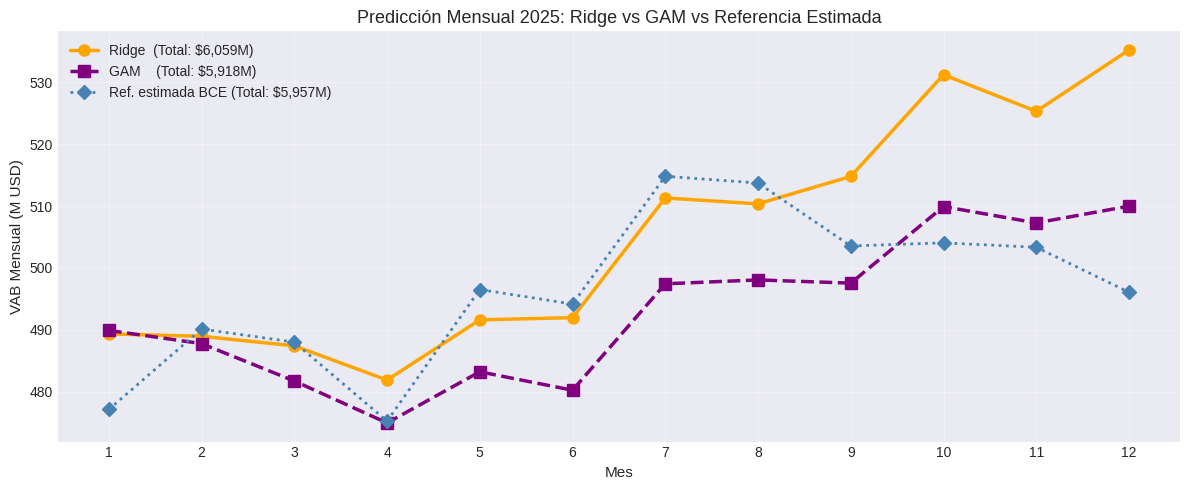

Referencia total: $5,956.70M (debe ser ~5956.7M)


In [ ]:
# =================================================================
# FIGURA MENSUAL 2025 CON REFERENCIA DISTRIBUIDA POR SENTIMIENTO
# =================================================================

VAB_REAL_2025 = 5956.70

sent_2025 = df_sentimiento[df_sentimiento['año'] == 2025].copy()
sent_2025 = sent_2025.sort_values('mes').reset_index(drop=True)

# Distribución del VAB estimado 2025 por sentimiento mensual
offset = abs(sent_2025['sentimiento_promedio'].min()) + 1
sent_2025['peso'] = sent_2025['sentimiento_promedio'] + offset
sent_2025['peso'] = sent_2025['peso'] / sent_2025['peso'].sum()
sent_2025['vab_ref'] = VAB_REAL_2025 * sent_2025['peso']

meses   = sent_2025['mes'].values
vab_ref = sent_2025['vab_ref'].values

df_r = pd.DataFrame(predicciones_2025)
df_g = pd.DataFrame(predicciones_2025_gam)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(meses, df_r['vab_predicho'], 'o-', color='orange', linewidth=2.5,
        markersize=8, label=f'Ridge  (Total: ${df_r["vab_predicho"].sum():,.0f}M)')
ax.plot(meses, df_g['vab_predicho'], 's--', color='purple', linewidth=2.5,
        markersize=8, label=f'GAM    (Total: ${df_g["vab_predicho"].sum():,.0f}M)')
ax.plot(meses, vab_ref, 'D:', color='steelblue', linewidth=2,
        markersize=7, label=f'Ref. estimada BCE (Total: ${vab_ref.sum():,.0f}M)')

ax.set_title('Predicción Mensual 2025: Ridge vs GAM vs Referencia Estimada', fontsize=13)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('VAB Mensual (M USD)', fontsize=11)
ax.set_xticks(meses)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figura_mensual_2025_con_referencia.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Referencia total: ${vab_ref.sum():,.2f}M (debe ser ~{VAB_REAL_2025}M)")


COMPARACIÓN DE LOS TRES MODELOS - PREDICCIÓN 2025

Predicciones anuales 2025:
  Modelo                                  VAB 2025     Variación
  ARIMA Actualizado                   $    5776.45        +0.14%
  Ridge + Sentimiento                 $    6059.45        +5.05%
  GAM + Sentimiento                   $    5917.98        +2.59%


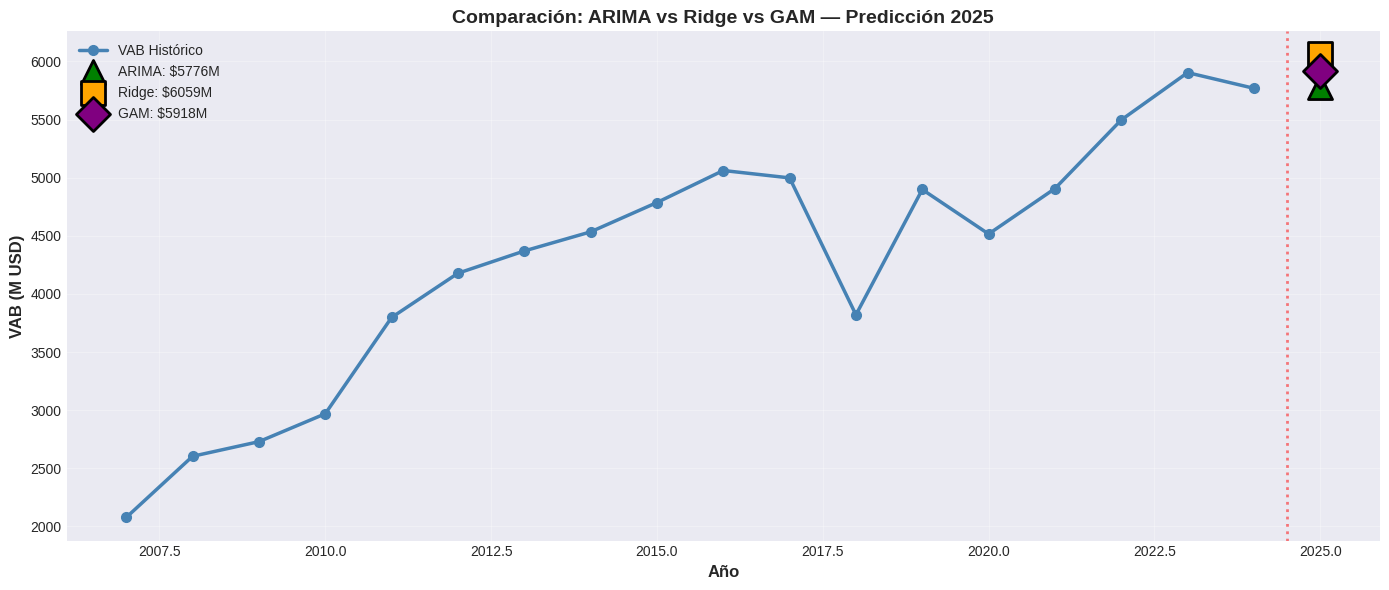

In [ ]:
# =================================================================
# BLOQUE 9 (NUEVO): COMPARACIÓN ARIMA vs RIDGE vs GAM — 2025
# =================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE LOS TRES MODELOS - PREDICCIÓN 2025")
print("=" * 70)

if prediccion_vab_2025_arima and vab_2025_sentimiento and vab_2025_gam:
    print("\nPredicciones anuales 2025:")
    print("=" * 70)
    print(f"  {'Modelo':<35} {'VAB 2025':>12}  {'Variación':>12}")
    print("=" * 70)
    print(f"  {'ARIMA Actualizado':<35} ${prediccion_vab_2025_arima:>11.2f}  {tasa_var_2025_arima:>+11.2f}%")
    print(f"  {'Ridge + Sentimiento':<35} ${vab_2025_sentimiento:>11.2f}  {tasa_var_2025_sentimiento:>+11.2f}%")
    print(f"  {'GAM + Sentimiento':<35} ${vab_2025_gam:>11.2f}  {tasa_var_2025_gam:>+11.2f}%")
    print("=" * 70)

    # Gráfico histórico + tres predicciones
    plt.figure(figsize=(14, 6))

    serie_vab = df_vab_completo['vab_corriente'].values
    años_vab  = df_vab_completo['año'].values

    plt.plot(años_vab, serie_vab, 'o-',
             label='VAB Histórico', linewidth=2.5, markersize=7, color='steelblue')

    plt.scatter([2025], [prediccion_vab_2025_arima],
                color='green', s=300, marker='^', zorder=5, edgecolors='black', linewidths=2,
                label=f'ARIMA: ${prediccion_vab_2025_arima:.0f}M')
    plt.scatter([2025], [vab_2025_sentimiento],
                color='orange', s=300, marker='s', zorder=5, edgecolors='black', linewidths=2,
                label=f'Ridge: ${vab_2025_sentimiento:.0f}M')
    plt.scatter([2025], [vab_2025_gam],
                color='purple', s=300, marker='D', zorder=5, edgecolors='black', linewidths=2,
                label=f'GAM: ${vab_2025_gam:.0f}M')

    plt.axvline(x=2024.5, color='red', linestyle=':', alpha=0.5, linewidth=2)
    plt.xlabel('Año', fontsize=12, fontweight='bold')
    plt.ylabel('VAB (M USD)', fontsize=12, fontweight='bold')
    plt.title('Comparación: ARIMA vs Ridge vs GAM — Predicción 2025',
              fontweight='bold', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)



VALIDACIÓN CON VAB REAL 2025 — TRES MODELOS

VAB Real 2025 (BCE): $5956.70M
Variación real vs 2024: +3.26%

Resultados de validación:
  Modelo                           Predicción     Error Abs     Error %
  Real 2025                      $    5956.70             —           —
  ARIMA Actualizado              $    5776.45  $     180.25       3.03%
  Ridge + Sentimiento            $    6059.45  $     102.75       1.72%
  GAM + Sentimiento              $    5917.98  $      38.72       0.65%

Mejor modelo: GAM + Sentimiento (error 0.65%)
  Ridge + Sentimiento: +43.0% vs ARIMA
  GAM + Sentimiento: +78.5% vs ARIMA

RESUMEN VALIDACIÓN CRUZADA: 2024 + 2025

  Modelo                           Error 2024    Error 2025    Promedio
  --------------------------------------------------------------------
  ARIMA                                 2.01%         3.03%       2.52%
  Ridge + Sentimiento                   0.40%         1.72%       1.06%
  GAM + Sentimiento                     0.84%        

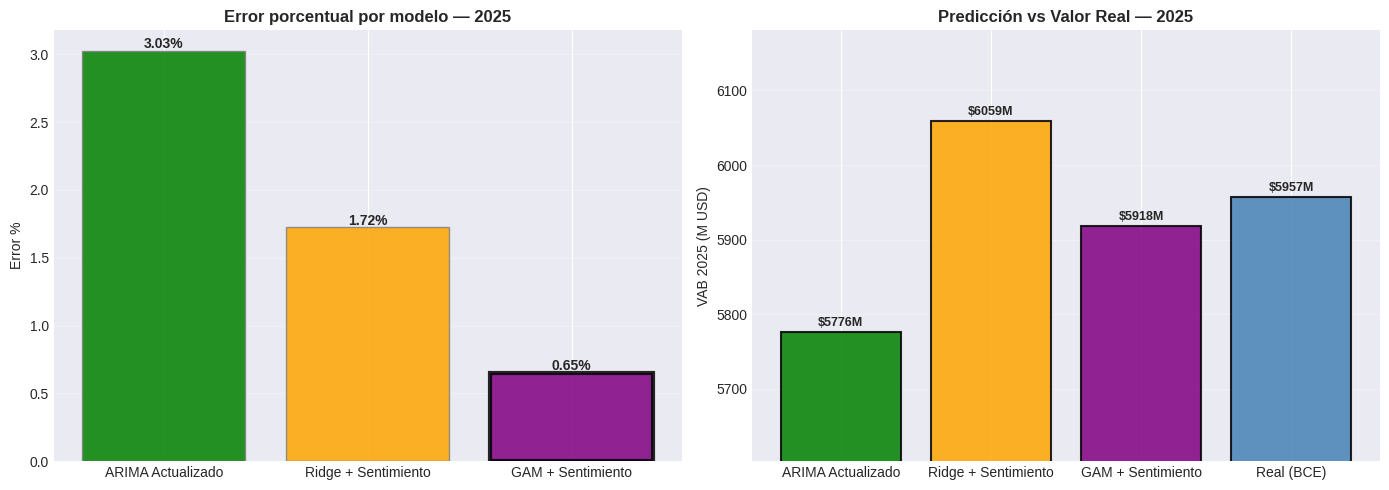

In [ ]:
# =================================================================
# BLOQUE 10 (NUEVO): VALIDACIÓN CON VAB REAL 2025 — TRES MODELOS
# =================================================================

print("\n" + "=" * 70)
print("VALIDACIÓN CON VAB REAL 2025 — TRES MODELOS")
print("=" * 70)

vab_real_2025 = 5956.70  # Millones USD (BCE)

vab_2024_ref = vab_2024_real
tasa_var_real_2025 = ((vab_real_2025 - vab_2024_ref) / vab_2024_ref) * 100

print(f"\nVAB Real 2025 (BCE): ${vab_real_2025:.2f}M")
print(f"Variación real vs 2024: {tasa_var_real_2025:+.2f}%")

resultados_3 = []

if prediccion_vab_2025_arima:
    e = abs(prediccion_vab_2025_arima - vab_real_2025)
    resultados_3.append({
        'Modelo':     'ARIMA Actualizado',
        'Prediccion': prediccion_vab_2025_arima,
        'Error Abs':  e,
        'Error %':    (e / vab_real_2025) * 100,
        'color':      'green'
    })

if vab_2025_sentimiento:
    e = abs(vab_2025_sentimiento - vab_real_2025)
    resultados_3.append({
        'Modelo':     'Ridge + Sentimiento',
        'Prediccion': vab_2025_sentimiento,
        'Error Abs':  e,
        'Error %':    (e / vab_real_2025) * 100,
        'color':      'orange'
    })

if vab_2025_gam:
    e = abs(vab_2025_gam - vab_real_2025)
    resultados_3.append({
        'Modelo':     'GAM + Sentimiento',
        'Prediccion': vab_2025_gam,
        'Error Abs':  e,
        'Error %':    (e / vab_real_2025) * 100,
        'color':      'purple'
    })

print("\nResultados de validación:")
print("=" * 80)
print(f"  {'Modelo':<30} {'Predicción':>12}  {'Error Abs':>12}  {'Error %':>10}")
print("=" * 80)
print(f"  {'Real 2025':<30} ${vab_real_2025:>11.2f}  {'—':>12}  {'—':>10}")
for r in resultados_3:
    print(f"  {r['Modelo']:<30} ${r['Prediccion']:>11.2f}  ${r['Error Abs']:>11.2f}  {r['Error %']:>9.2f}%")
print("=" * 80)

# Ganador y mejoras vs ARIMA
if resultados_3:
    mejor = min(resultados_3, key=lambda x: x['Error %'])
    print(f"\nMejor modelo: {mejor['Modelo']} (error {mejor['Error %']:.2f}%)")

    baseline = next((r for r in resultados_3 if r['Modelo'] == 'ARIMA Actualizado'), None)
    if baseline:
        for r in resultados_3:
            if r['Modelo'] != 'ARIMA Actualizado':
                mejora = ((baseline['Error Abs'] - r['Error Abs']) / baseline['Error Abs']) * 100
                print(f"  {r['Modelo']}: {mejora:+.1f}% vs ARIMA")

# Resumen cruzado 2024 + 2025
print("\n" + "=" * 70)
print("RESUMEN VALIDACIÓN CRUZADA: 2024 + 2025")
print("=" * 70)

ridge_2025 = next((r for r in resultados_3 if r['Modelo'] == 'Ridge + Sentimiento'), None)
gam_2025   = next((r for r in resultados_3 if r['Modelo'] == 'GAM + Sentimiento'), None)
arima_2025 = next((r for r in resultados_3 if r['Modelo'] == 'ARIMA Actualizado'), None)

print(f"\n  {'Modelo':<30} {'Error 2024':>12}  {'Error 2025':>12}  {'Promedio':>10}")
print(f"  {'-'*68}")
print(f"  {'ARIMA':<30} {'2.01%':>12}  {arima_2025['Error %']:>11.2f}%  {(2.01 + arima_2025['Error %'])/2:>9.2f}%")
if ridge_2025:
    print(f"  {'Ridge + Sentimiento':<30} {'0.40%':>12}  {ridge_2025['Error %']:>11.2f}%  {(0.40 + ridge_2025['Error %'])/2:>9.2f}%")
if gam_2025:
    print(f"  {'GAM + Sentimiento':<30} {'0.84%':>12}  {gam_2025['Error %']:>11.2f}%  {(0.84 + gam_2025['Error %'])/2:>9.2f}%")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = [r['Modelo'] for r in resultados_3]
errores = [r['Error %'] for r in resultados_3]
colores = [r['color'] for r in resultados_3]
min_err = min(errores)
edges   = ['black' if e == min_err else 'gray' for e in errores]
lws     = [3 if e == min_err else 1 for e in errores]

axes[0].bar(nombres, errores, color=colores, alpha=0.85, edgecolor=edges, linewidth=lws)
axes[0].set_title('Error porcentual por modelo — 2025', fontweight='bold')
axes[0].set_ylabel('Error %')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(errores):
    axes[0].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)

preds = [r['Prediccion'] for r in resultados_3] + [vab_real_2025]
noms  = [r['Modelo'] for r in resultados_3] + ['Real (BCE)']
cols2 = [r['color'] for r in resultados_3] + ['steelblue']
axes[1].bar(noms, preds, color=cols2, alpha=0.85, edgecolor='black', linewidth=1.5)
axes[1].set_title('Predicción vs Valor Real — 2025', fontweight='bold')
axes[1].set_ylabel('VAB 2025 (M USD)')
axes[1].set_ylim(min(preds)*0.97, max(preds)*1.02)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(preds):
    axes[1].text(i, v + 8, f'${v:.0f}M', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)


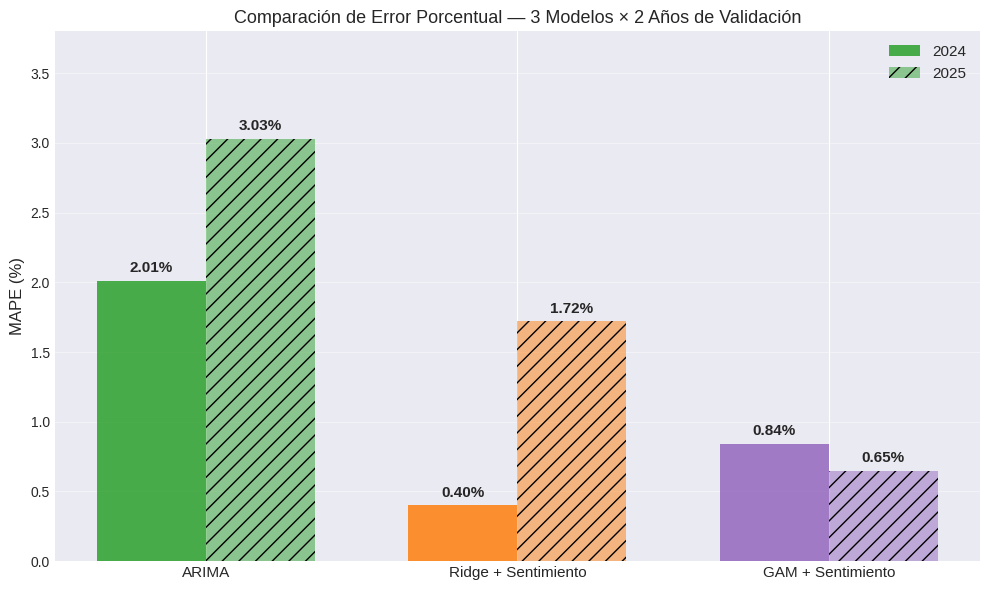

Figura guardada: figura_comparativa_general.png


In [ ]:
# =================================================================
# BLOQUE EXTRA: FIGURA COMPARATIVA GENERAL — 3 MODELOS × 2 AÑOS
# =================================================================

import matplotlib.pyplot as plt
import numpy as np

modelos = ['ARIMA', 'Ridge + Sentimiento', 'GAM + Sentimiento']
mape_2024 = [2.01, 0.40, 0.84]
mape_2025 = [3.03, 1.72, 0.65]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, mape_2024, width, label='2024', color=['#2ca02c','#ff7f0e','#9467bd'], alpha=0.85)
bars2 = ax.bar(x + width/2, mape_2025, width, label='2025', color=['#2ca02c','#ff7f0e','#9467bd'], alpha=0.5, hatch='//')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('Comparación de Error Porcentual — 3 Modelos × 2 Años de Validación', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 3.8)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figura_comparativa_general.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figura_comparativa_general.png")